### Load Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_PATH = Path("../../dataset/mesogeos_wildfire_dataset.csv")

df = pd.read_csv(DATASET_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (11305, 32)


,date,latitude,longitude,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,...,lc_grassland,lc_settlement,lc_shrubland,lc_sparse_vegetation,lc_water_bodies,lc_wetland,burned_area_ha,year,month,day_of_year
0,2006-08-27,38.123648,-7.819233,36.419031,15.989252,22.510025,3.511700,329.388733,0.000000,99694.617188,...,0.0,0.0,0.000000,0.0,0.0,0.0,40.0,2006,8,239
1,2006-08-11,42.000202,0.447392,27.559045,7.369226,16.027991,6.567619,296.081879,0.004796,93547.523438,...,0.0,0.0,0.192824,0.0,0.0,0.0,1390.0,2006,8,223
2,2006-07-11,41.617581,-8.524061,34.471796,20.400690,35.828364,2.905688,345.955994,0.550396,99709.054688,...,0.0,0.0,0.000000,0.0,0.0,0.0,173.0,2006,7,192
3,2006-09-07,41.557167,-7.567509,30.666193,12.939386,28.009099,2.133366,313.057190,2.396404,93731.859375,...,0.0,0.0,0.000000,0.0,0.0,0.0,220.0,2006,9,250
4,2006-09-08,41.547098,-6.248474,31.690332,14.382166,22.408468,3.914824,288.407166,0.974770,93459.937500,...,0.0,0.0,0.000000,0.0,0.0,0.0,76.0,2006,9,251


### Inspect the dataset structur

In [3]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.info()

Rows: 11305
Columns: 32
<class 'pandas.DataFrame'>
RangeIndex: 11305 entries, 0 to 11304
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  11305 non-null  str    
 1   latitude              11305 non-null  float64
 2   longitude             11305 non-null  float64
 3   temperature_c         9844 non-null   float64
 4   dew_point_c           9844 non-null   float64
 5   relative_humidity     9844 non-null   float64
 6   wind_speed            9844 non-null   float64
 7   wind_direction        10891 non-null  float64
 8   rainfall_mm           9844 non-null   float64
 9   surface_pressure      9844 non-null   float64
 10  solar_radiation       9844 non-null   float64
 11  ndvi                  11265 non-null  float64
 12  lai                   11120 non-null  float64
 13  soil_moisture         10171 non-null  float64
 14  elevation             11305 non-null  float64
 15  slope_

### Feature Inventory

In [4]:
feature_inventory = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "missing_%": (df.isna().mean() * 100).round(2).values,
    "unique_values": df.nunique().values
})

display(feature_inventory)

,feature,dtype,missing,missing_%,unique_values
0,date,str,0,0.00,2819
1,latitude,float64,0,0.00,1347
2,longitude,float64,0,0.00,3431
3,temperature_c,float64,1461,12.92,9780
4,dew_point_c,float64,1461,12.92,9773
5,relative_humidity,float64,1461,12.92,9838
6,wind_speed,float64,1461,12.92,9840
7,wind_direction,float64,414,3.66,10883
8,rainfall_mm,float64,1461,12.92,5239
9,surface_pressure,float64,1461,12.92,9820


## Interpretation — Feature Inventory

The Mesogeos wildfire dataset contains **11,305 observations and 32 variables**.

The dataset contains meteorological, environmental, terrain, land-cover, geographic, and temporal variables that can potentially contribute to wildfire burned-area prediction.

Several meteorological variables, including temperature, dew point, relative humidity, wind speed, rainfall, surface pressure, and solar radiation, contain approximately **12.92% missing observations**. Soil moisture contains approximately **10.03% missing observations**, while LAI, NDVI, and population have considerably smaller amounts of missing data.

Importantly, the target variable `burned_area_ha` contains **no missing values**, meaning that all extracted wildfire records have a known burned-area value.

The land-cover variables contain continuous values between 0 and 1 and therefore appear to represent the proportion or fraction of the corresponding land-cover type within the sampled area rather than simple categorical classes.

The year variable contains 17 distinct years, while the month and day-of-year variables represent temporal information that can later be used for seasonal feature engineering.

At this stage, no observations or variables are removed. The missing values and feature distributions will be investigated further before a preprocessing strategy is selected.

### Investigate Missing Values

In [5]:
weather_cols = [
    "temperature_c",
    "dew_point_c",
    "relative_humidity",
    "wind_speed",
    "wind_direction",
    "rainfall_mm",
    "surface_pressure",
    "solar_radiation"
]

print("Missing weather values by year:")

display(
    df.groupby("year")[weather_cols]
      .apply(lambda x: x.isna().sum())
)

print("\nMissing weather values by month:")

display(
    df.groupby("month")[weather_cols]
      .apply(lambda x: x.isna().sum())
)

Missing weather values by year:


,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,solar_radiation
year,,,,,,,,
2006,44,44,44,44,12,44,44,44
2007,82,82,82,82,33,82,82,82
2008,53,53,53,53,8,53,53,53
2009,62,62,62,62,22,62,62,62
2010,47,47,47,47,13,47,47,47
2011,103,103,103,103,26,103,103,103
2012,146,146,146,146,41,146,146,146
2013,46,46,46,46,14,46,46,46
2014,41,41,41,41,10,41,41,41



Missing weather values by month:


,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,solar_radiation
month,,,,,,,,
1,11,11,11,11,6,11,11,11
2,26,26,26,26,6,26,26,26
3,30,30,30,30,8,30,30,30
4,18,18,18,18,6,18,18,18
5,34,34,34,34,12,34,34,34
6,154,154,154,154,37,154,154,154
7,436,436,436,436,127,436,436,436
8,483,483,483,483,139,483,483,483
9,191,191,191,191,51,191,191,191


## Interpretation — Missing Weather Values

The investigation shows that missing meteorological observations occur throughout the complete 2006–2022 study period rather than being restricted to a single year.

The missing values are also concentrated in the summer months, particularly July and August. However, these months contain substantially more wildfire records than the other months. Therefore, raw missing-value counts alone cannot determine whether the probability of missing data is actually higher during the summer fire season.

The missingness pattern will therefore be evaluated using percentages relative to the number of observations in each year and month.

An additional observation is that `wind_direction` has substantially fewer missing values than the other main meteorological variables. This suggests that different variables may have different missing-data patterns.

At this stage, no missing values are removed or imputed. The missing-data mechanism will be investigated further before selecting an appropriate preprocessing strategy.

### Calculate the missing-data percentages

In [6]:
# MISSING WEATHER PERCENTAGE BY YEAR

year_total = df.groupby("year").size()

year_missing_percent = (
    df.groupby("year")[weather_cols]
      .apply(lambda x: x.isna().mean() * 100)
)

print("Missing weather percentage by year:")
display(year_missing_percent.round(2))

# MISSING WEATHER PERCENTAGE BY MONTH

month_total = df.groupby("month").size()

month_missing_percent = (
    df.groupby("month")[weather_cols]
      .apply(lambda x: x.isna().mean() * 100)
)

print("\nMissing weather percentage by month:")
display(month_missing_percent.round(2))

Missing weather percentage by year:


,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,solar_radiation
year,,,,,,,,
2006,20.56,20.56,20.56,20.56,5.61,20.56,20.56,20.56
2007,13.60,13.60,13.60,13.60,5.47,13.60,13.60,13.60
2008,17.91,17.91,17.91,17.91,2.70,17.91,17.91,17.91
2009,13.60,13.60,13.60,13.60,4.82,13.60,13.60,13.60
2010,11.19,11.19,11.19,11.19,3.10,11.19,11.19,11.19
2011,13.19,13.19,13.19,13.19,3.33,13.19,13.19,13.19
2012,13.96,13.96,13.96,13.96,3.92,13.96,13.96,13.96
2013,10.85,10.85,10.85,10.85,3.30,10.85,10.85,10.85
2014,12.81,12.81,12.81,12.81,3.12,12.81,12.81,12.81



Missing weather percentage by month:


,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,solar_radiation
month,,,,,,,,
1,7.01,7.01,7.01,7.01,3.82,7.01,7.01,7.01
2,6.93,6.93,6.93,6.93,1.60,6.93,6.93,6.93
3,2.93,2.93,2.93,2.93,0.78,2.93,2.93,2.93
4,4.38,4.38,4.38,4.38,1.46,4.38,4.38,4.38
5,17.17,17.17,17.17,17.17,6.06,17.17,17.17,17.17
6,21.78,21.78,21.78,21.78,5.23,21.78,21.78,21.78
7,15.79,15.79,15.79,15.79,4.60,15.79,15.79,15.79
8,13.47,13.47,13.47,13.47,3.88,13.47,13.47,13.47
9,14.55,14.55,14.55,14.55,3.88,14.55,14.55,14.55


## Interpretation — Missing-Data Percentages

The percentage-based analysis shows that missing meteorological observations are distributed across the study period and vary by both year and month.

For the main meteorological variables, annual missingness ranges from approximately 9% to 21%. The highest missing rate occurs in 2006 (20.56%), while 2019 has the lowest rate (9.01%). The `wind_direction` variable has considerably lower missingness, generally remaining below approximately 6%.

Monthly missingness also varies substantially. June has the highest missing rate at approximately 21.78%, followed by May at 17.17%. March has the lowest rate at approximately 2.93%.

Therefore, the missing values do not appear to be uniformly distributed across time. However, the dataset still contains a large number of valid observations and the target variable `burned_area_ha` has no missing values.

The weather variables will therefore be retained. Missing values will be handled during the preprocessing stage using an appropriate imputation strategy. The imputation parameters will be learned only from the training data to prevent data leakage.

No rows are removed at this stage.

### Duplicate Investigation

In [7]:
# Check for completely duplicated records
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print("\nDuplicate records:")
    display(df[df.duplicated(keep=False)].sort_values(
        by=["date", "latitude", "longitude"]
    ))
else:
    print("No duplicate records found.")

Duplicate rows: 2

Duplicate records:


,date,latitude,longitude,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,...,lc_grassland,lc_settlement,lc_shrubland,lc_sparse_vegetation,lc_water_bodies,lc_wetland,burned_area_ha,year,month,day_of_year
7716,2019-12-30,43.178272,-6.399508,11.799799,4.803339,42.646006,2.036749,181.545166,0.000010,93030.632812,...,0.350848,0.0,0.0,0.0,0.0,0.0,126.0,2019,12,364
8172,2019-12-30,43.178272,-6.399508,11.799799,4.803339,42.646006,2.036749,181.545166,0.000010,93030.632812,...,0.350848,0.0,0.0,0.0,0.0,0.0,126.0,2019,12,364
10087,2021-12-28,43.178272,-6.389439,13.648492,9.709192,73.061812,3.787528,205.027756,0.450703,92098.796875,...,0.035176,0.0,0.0,0.0,0.0,0.0,95.0,2021,12,362
10103,2021-12-28,43.178272,-6.389439,13.648492,9.709192,73.061812,3.787528,205.027756,0.450703,92098.796875,...,0.035176,0.0,0.0,0.0,0.0,0.0,95.0,2021,12,362


## Interpretation — Duplicate Records

The dataset contains **2 exact duplicate records**. Because each duplicate appears twice, four rows are displayed when both copies are shown using `keep=False`.

The duplicated observations correspond to wildfire records dated 2019-12-30 and 2021-12-28. The duplicated rows contain identical values across all 32 columns, including their geographic coordinates, environmental conditions, land-cover information, and burned-area measurements.

These records do not appear to represent separate wildfire events. Keeping duplicate observations could cause certain samples to receive additional weight during model training and may contribute to biased model evaluation, particularly if duplicate observations are distributed between training and testing sets.

Therefore, one copy of each exact duplicate will be removed during the preprocessing stage. The original investigation dataset will remain unchanged at this stage.

### Investigate the target variable

In [8]:
# TARGET VARIABLE — BASIC STATISTICS

target = "burned_area_ha"

print("Target variable:", target)
print("Number of observations:", df[target].count())
print("Missing values:", df[target].isna().sum())

print("\nDescriptive statistics:")
display(df[target].describe())

print("\nSelected percentiles:")
display(
    df[target].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00]
    ).rename("burned_area_ha")
)

Target variable: burned_area_ha
Number of observations: 11305
Missing values: 0

Descriptive statistics:


count     11305.000000
mean        489.286953
std        2093.071924
min          30.000000
25%          66.000000
50%         131.000000
75%         335.000000
max      107602.000000
Name: burned_area_ha, dtype: float64


Selected percentiles:


0.500       131.00
0.750       335.00
0.900       868.60
0.950      1665.00
0.990      5900.20
0.995     10197.08
1.000    107602.00
Name: burned_area_ha, dtype: float64

## Interpretation — Target Variable

The target variable `burned_area_ha` contains 11,305 valid wildfire observations and has no missing values.

The distribution is strongly right-skewed. The median burned area is 131 hectares, while the mean is substantially higher at approximately 489 hectares. This difference indicates that a relatively small number of very large wildfire events have a strong influence on the mean.

The percentile analysis further demonstrates the long-tailed nature of the target. Approximately 90% of observations have burned areas below 868.6 hectares, while the 99th percentile is 5,900.2 hectares. However, the maximum recorded burned area is 107,602 hectares.

This indicates the presence of a small number of extreme wildfire events. These observations should not automatically be treated as errors because very large wildfires are physically possible and may represent genuine events.

The strong right-skewness is important for regression modelling because extreme target values can disproportionately influence model training and evaluation. The distribution will therefore be visualized and compared with a logarithmic transformation before deciding how the target should be handled during model development.

### Raw Target Distribution

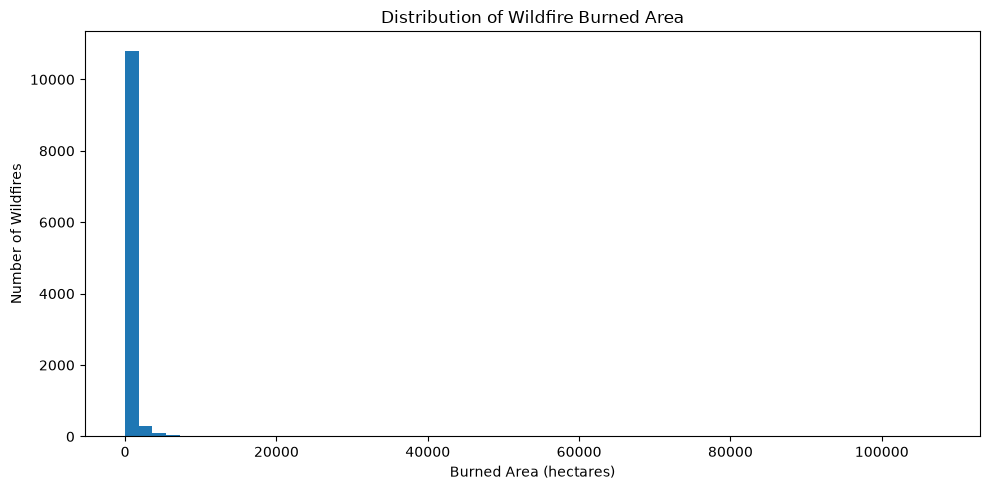

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(df["burned_area_ha"], bins=60)

plt.title("Distribution of Wildfire Burned Area")
plt.xlabel("Burned Area (hectares)")
plt.ylabel("Number of Wildfires")

plt.tight_layout()
plt.show()